EXPERIMENT :- 1 Demonstration and implementation of Shallow architecture, using Python, Tensorflow and Keras.

In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [17]:
# Load the Wine dataset from sklearn
data = load_wine()
X = data.data
y = data.target
class_names = data.target_names

print(f"Features Shape: {X.shape}")
print(f"Target Shape: {y.shape}")
print(f"Classes: {class_names}")

#data as a DataFrame
df = pd.DataFrame(X, columns=data.feature_names)
df.head()

Features Shape: (178, 13)
Target Shape: (178,)
Classes: ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [18]:
#Split into Train (80%) and Test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Data standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [19]:
model = keras.Sequential([
    #Input Layer
    keras.Input(shape=(13,)),

    # Hidden Layer
    layers.Dense(16, activation='relu', name="Hidden_Layer"),

    # Output Layer
    layers.Dense(3, activation='softmax', name="Output_Layer")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer (Dense)            │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275 (1.07 KB)

 Trainable params: 275 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
history = model.fit(
    X_train,
    y_train,
    batch_size=16,
    epochs=50,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.0270 - loss: 1.6118 - val_accuracy: 0.0000e+00 - val_loss: 1.6529
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0478 - loss: 1.5367 - val_accuracy: 0.0667 - val_loss: 1.5452
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1052 - loss: 1.4729 - val_accuracy: 0.1333 - val_loss: 1.4475
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1735 - loss: 1.3152 - val_accuracy: 0.2000 - val_loss: 1.3594
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2427 - loss: 1.2223 - val_accuracy: 0.2667 - val_loss: 1.2789
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2793 - loss: 1.1751 - val_accuracy: 0.3333 - val_loss: 1.2106
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4386 - loss: 1.0737 - val_accuracy: 0.5333 - val_loss: 1.1500
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4737 - loss: 1.0077 - val_accuracy: 0.5333 - val_loss: 1.0893
Epo

In [23]:
#Check accuracy on test data
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {acc*100:.2f}%")

sample_data = X_test[0].reshape(1, 13)
actual_class = y_test[0]

# Predict
probabilities = model.predict(sample_data)
predicted_class = np.argmax(probabilities)

print("\n--- Prediction Result ---")
print(f"Probabilities: {probabilities}")
print(f"Predicted Class: {predicted_class} ({class_names[predicted_class]})")
print(f"Actual Class:    {actual_class} ({class_names[actual_class]})")


Test Accuracy: 97.22%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

--- Prediction Result ---
Probabilities: [[0.9827692  0.00631077 0.01092   ]]
Predicted Class: 0 (class_0)
Actual Class:    0 (class_0)


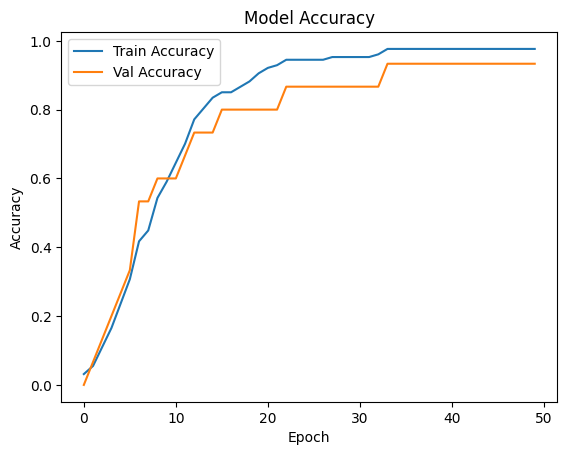

In [24]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()